In [1]:
import json
import pickle
import warnings
import datetime
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Paths
PROCESSED_DIR = Path("../../../data/processed/02_lstm_ae_personalized_model")
MODEL_DIR     = Path("../../../model/02_lstm_ae_personalized_model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Window config
WINDOW_SIZE = 14
STRIDE      = 14 

# **LOAD DATA**

In [3]:
df = pd.read_csv(PROCESSED_DIR / "daily_spending_matrix.csv", parse_dates=['tanggal'])

with open(PROCESSED_DIR / "feature_cols.json") as f:
    FEATURE_COLS = json.load(f)

N_FEATURES = len(FEATURE_COLS)

df.sort_values(['id_user', 'tanggal'], inplace=True)
df.reset_index(drop=True, inplace=True)

assert df[FEATURE_COLS].isna().sum().sum() == 0, "Ada NaN di FEATURE_COLS!"
days_per_user = df.groupby('id_user')['tanggal'].count()

In [4]:
print(f"Shape DataFrame     : {df.shape}")
print(f"Total unique users  : {df['id_user'].nunique()}")
print(f"Hari per user — min : {days_per_user.min()} | max : {days_per_user.max()} | mean : {days_per_user.mean():.1f}")
print(f"\nFEATURE_COLS ({N_FEATURES} fitur):")
for col in FEATURE_COLS:
    print(f"* {col}")


Shape DataFrame     : (40523, 19)
Total unique users  : 500
Hari per user — min : 60 | max : 90 | mean : 81.0

FEATURE_COLS (17 fitur):
* Belanja Online & Fashion
* F&B dan Nongkrong
* Groceries & Kebutuhan Pokok
* Hiburan & Langganan
* Investasi & Finansial
* Kesehatan & Perawatan Diri
* NLP Classified Transfer
* Produktivitas & Digital
* Tagihan & Utilitas
* Transportasi
* gaji_bulanan
* segmen_demografi_enc
* persona_dasar_enc
* dow_sin
* dow_cos
* dom_sin
* dom_cos


# **TRAIN-TEST SPLIT** 

Split dilakukan per user secara temporal: 80% hari pertama untuk train, 20% hari terakhir untuk val.

In [5]:
train_parts = []
val_parts   = []

for uid, grp in df.groupby('id_user', sort=False):
    grp = grp.sort_values('tanggal')
    cut = int(len(grp) * 0.8)
    train_parts.append(grp.iloc[:cut])
    val_parts.append(grp.iloc[cut:])

df_train = pd.concat(train_parts).reset_index(drop=True)
df_val   = pd.concat(val_parts).reset_index(drop=True)

print(f"Train rows : {len(df_train)}")
print(f"Val rows   : {len(df_val)}")

Train rows : 32242
Val rows   : 8281


# **PRE-PROCESSING**

#### **Scalling (Min-Max Scaller)**

In [6]:
# Simpan salinan unscaled sebelum transform (dibutuhkan untuk active-day masking)
df_train_raw = df_train.copy()
df_val_raw   = df_val.copy()

scaler = MinMaxScaler()
df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
df_val[FEATURE_COLS]   = scaler.transform(df_val[FEATURE_COLS])

with open(MODEL_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

scaled_min = df_train[FEATURE_COLS].min().min()
scaled_max = df_train[FEATURE_COLS].max().max()
print(f"Range nilai setelah scaling (train) — min: {scaled_min:.4f} | max: {scaled_max:.4f}")
print("Scaler disimpan: scaler.pkl")

Range nilai setelah scaling (train) — min: 0.0000 | max: 1.0000
Scaler disimpan: scaler.pkl


#### **Sliding Window (Stride=14)**

In [7]:
def build_windows(df_user, feature_cols, window_size, stride):
    """
    Membentuk sliding window non-overlapping per user.
    Returns array of shape [n_windows, window_size, n_features]
    dan metadata tanggal akhir tiap window.
    """
    values    = df_user[feature_cols].values
    dates     = df_user['tanggal'].values
    windows   = []
    end_dates = []

    for start in range(0, len(values) - window_size + 1, stride):
        end = start + window_size
        windows.append(values[start:end])
        end_dates.append(dates[end - 1])

    return np.array(windows), end_dates

In [ ]:
all_train_windows     = []
all_train_windows_raw = []
train_user_ids        = []
train_end_dates       = []

all_val_windows       = []
all_val_windows_raw   = []
val_user_ids          = []
val_end_dates         = []

users_in_training     = []

# Jumlah kolom kategori (sebelum gaji_bulanan, segmen, persona, temporal)
N_CAT        = FEATURE_COLS.index('gaji_bulanan')
MIN_ACTIVE   = 3    # window dibuang jika hari aktif < 3

for uid in df_train['id_user'].unique():
    grp_train     = df_train[df_train['id_user'] == uid].sort_values('tanggal')
    grp_train_raw = df_train_raw[df_train_raw['id_user'] == uid].sort_values('tanggal')
    grp_val       = df_val[df_val['id_user'] == uid].sort_values('tanggal')
    grp_val_raw   = df_val_raw[df_val_raw['id_user'] == uid].sort_values('tanggal')

    if len(grp_train) < WINDOW_SIZE:
        continue

    wins_t,     dates_t = build_windows(grp_train,     FEATURE_COLS, WINDOW_SIZE, STRIDE)
    wins_t_raw, _       = build_windows(grp_train_raw, FEATURE_COLS, WINDOW_SIZE, STRIDE)

    added_train = 0
    for w_scaled, w_raw, d in zip(wins_t, wins_t_raw, dates_t):
        if int((w_raw[:, :N_CAT].sum(axis=1) > 0).sum()) < MIN_ACTIVE:
            continue
        all_train_windows.append(w_scaled)
        all_train_windows_raw.append(w_raw)
        train_user_ids.append(uid)
        train_end_dates.append(d)
        added_train += 1

    if added_train > 0:
        users_in_training.append(uid)

    if len(grp_val) >= WINDOW_SIZE:
        wins_v,     dates_v = build_windows(grp_val,     FEATURE_COLS, WINDOW_SIZE, STRIDE)
        wins_v_raw, _       = build_windows(grp_val_raw, FEATURE_COLS, WINDOW_SIZE, STRIDE)

        for w_scaled, w_raw, d in zip(wins_v, wins_v_raw, dates_v):
            if int((w_raw[:, :N_CAT].sum(axis=1) > 0).sum()) < MIN_ACTIVE:
                continue
            all_val_windows.append(w_scaled)
            all_val_windows_raw.append(w_raw)
            val_user_ids.append(uid)
            val_end_dates.append(d)

X_train     = np.array(all_train_windows)       # [N_windows, 14, N_FEATURES]
X_train_raw = np.array(all_train_windows_raw)   # [N_windows, 14, N_FEATURES] —> unscaled
X_val       = np.array(all_val_windows)         # [N_windows, 14, N_FEATURES]
X_val_raw   = np.array(all_val_windows_raw)     # [N_windows, 14, N_FEATURES] —> unscaled

unique_train_users = list(dict.fromkeys(train_user_ids))

print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"Users masuk training : {len(unique_train_users)}")
print(f"NaN di X_train : {np.isnan(X_train).sum()}")
print(f"NaN di X_val   : {np.isnan(X_val).sum()}")

X_train shape : (1482, 14, 17)
X_val shape   : (341, 14, 17)
Users masuk training : 498
NaN di X_train : 0
NaN di X_val   : 0


# **MODEL**

In [9]:
# Model hyperparameter
ENCODER_UNITS = [128, 64, 32]
DECODER_UNITS = [32, 64, 128]
DROPOUT_RATE  = 0.2
LEARNING_RATE = 0.0001

In [10]:
def build_lstm_ae(window_size, n_features, encoder_units, decoder_units, dropout_rate):
    inputs = keras.Input(shape=(window_size, n_features))

    # Encoder
    x = inputs
    for i, units in enumerate(encoder_units):
        return_seq = (i < len(encoder_units) - 1)    # False hanya di layer terakhir
        x = layers.LSTM(units, return_sequences=return_seq, dropout=dropout_rate)(x)

    # Bottleneck
    x = layers.RepeatVector(window_size)(x)

    # Decoder
    for units in decoder_units:
        x = layers.LSTM(units, return_sequences=True, dropout=dropout_rate)(x)

    # Output
    outputs = layers.TimeDistributed(layers.Dense(n_features))(x)

    model = keras.Model(inputs, outputs, name="lstm_autoencoder")
    return model


model = build_lstm_ae(WINDOW_SIZE, N_FEATURES, ENCODER_UNITS, DECODER_UNITS, DROPOUT_RATE)
model.summary()

2026-05-13 17:39:29.894719: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-05-13 17:39:29.894762: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-05-13 17:39:29.894768: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-05-13 17:39:29.894801: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-13 17:39:29.894813: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 14, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 14, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 14, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 14, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 14, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 14, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 14, 17)         │         2,193 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,737 (1.03 MB)

 Trainable params: 270,737 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

# **TRAINING LOOP**

#### *****Custom Callback*****

In [ ]:
class LSTMAECallback(keras.callbacks.Callback):

    def __init__(self, patience=10, log_every=5):
        super().__init__()
        self.patience     = patience
        self.log_every    = log_every
        self.best_val_loss = np.inf
        self.wait         = 0
        self.best_weights = None
        self.stopped_epoch = 0

    def on_epoch_end(self, epoch, logs=None):
        val_loss   = logs.get('val_loss', np.inf)
        train_loss = logs.get('loss', np.inf)

        # logging setiap N epoch
        if (epoch + 1) % self.log_every == 0:
            print(f"Epoch {epoch+1:04d} | train_loss: {train_loss:.6f} | val_loss: {val_loss:.6f}")

        # early stopping logic
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.wait         = 0
            self.best_weights = self.model.get_weights() # Simpan model terbaik
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch   = epoch + 1
                self.model.stop_training = True
                print(f"\nEarly stopping di epoch {self.stopped_epoch}. Best val_loss: {self.best_val_loss:.6f}")

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
            print("Bobot model terbaik telah dikembalikan ke model.")

#### **Train**

In [12]:
# Training
EPOCHS                  = 100
BATCH_SIZE              = 64
VALIDATION_SPLIT        = 0.2
EARLY_STOPPING_PATIENCE = 8

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse'
)
callback = LSTMAECallback(patience=EARLY_STOPPING_PATIENCE, log_every=5)

history = model.fit(
    X_train, X_train,                        # autoencoder: target = input
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[callback],
    verbose=0                                # logging ditangani callback
)

2026-05-13 17:39:31.264296: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Epoch 0005 | train_loss: 0.073958 | val_loss: 0.073831
Epoch 0010 | train_loss: 0.057571 | val_loss: 0.060949
Epoch 0015 | train_loss: 0.051206 | val_loss: 0.055177
Epoch 0020 | train_loss: 0.045836 | val_loss: 0.048773
Epoch 0025 | train_loss: 0.041008 | val_loss: 0.042586
Epoch 0030 | train_loss: 0.037578 | val_loss: 0.040625
Epoch 0035 | train_loss: 0.035128 | val_loss: 0.039220
Epoch 0040 | train_loss: 0.032761 | val_loss: 0.037776
Epoch 0045 | train_loss: 0.030342 | val_loss: 0.036877
Epoch 0050 | train_loss: 0.025700 | val_loss: 0.037701

Early stopping di epoch 52. Best val_loss: 0.036749
Bobot model terbaik telah dikembalikan ke model.


In [14]:
model.save(MODEL_DIR / "lstm_ae_personalized.keras")
print(f"Model disimpan: {MODEL_DIR / 'lstm_ae_personalized.keras'}")

Model disimpan: ../../../model/02_lstm_ae_personalized_model/lstm_ae_personalized.keras


# **EVALUATION**

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


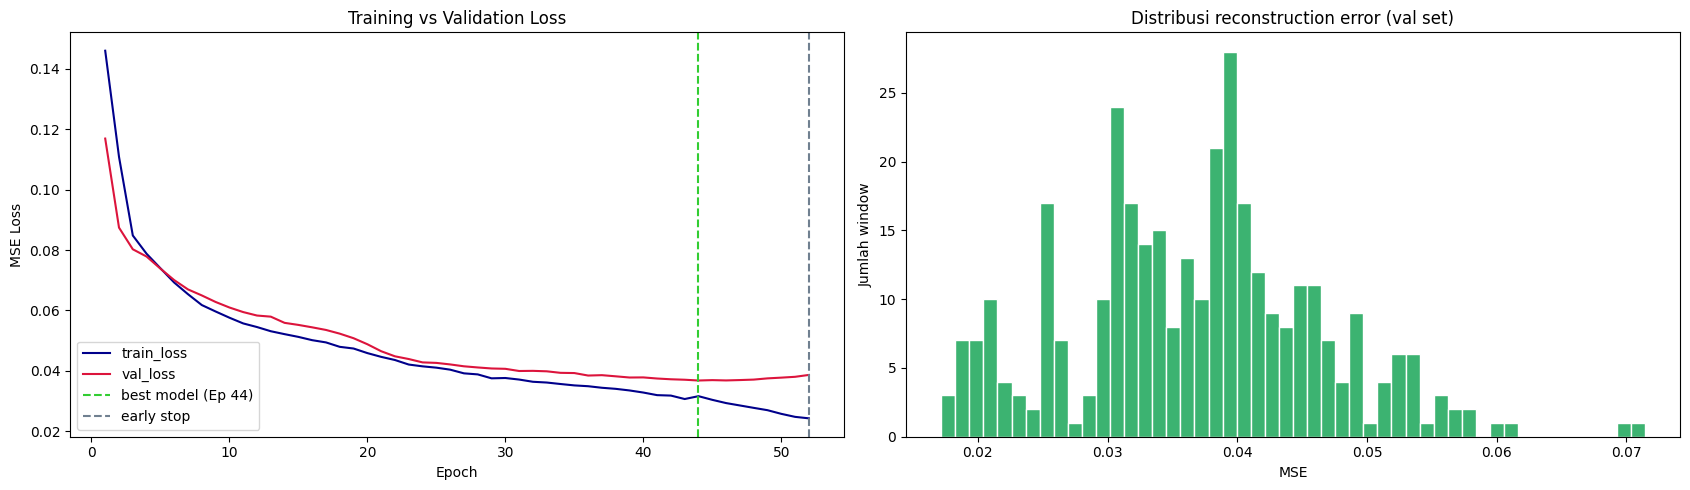

Val MSE — mean: 0.0367 | std: 0.0096 | p95: 0.0530 | max: 0.0714


In [15]:
X_val_pred      = model.predict(X_val)
mse_per_window  = np.mean((X_val - X_val_pred) ** 2, axis=(1, 2))

train_loss_hist = history.history['loss']
val_loss_hist   = history.history['val_loss']
epochs_range    = range(1, len(train_loss_hist) + 1)

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Plot 1: Loss curve
axes[0].plot(epochs_range, train_loss_hist, color='darkblue', label='train_loss')
axes[0].plot(epochs_range, val_loss_hist,   color='crimson',    label='val_loss')
best_epoch = np.argmin(val_loss_hist) + 1
axes[0].axvline(x=best_epoch, color='limegreen', linestyle='--', linewidth=1.5, label=f'best model (Ep {best_epoch})')
if callback.stopped_epoch > 0:
    axes[0].axvline(x=callback.stopped_epoch, color='slategray', linestyle='--', label='early stop')
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

# Plot 2: Reconstruction error distribution
axes[1].hist(mse_per_window, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title("Distribusi reconstruction error (val set)")
axes[1].set_xlabel("MSE")
axes[1].set_ylabel("Jumlah window")

plt.tight_layout()
plt.show()

print(f"Val MSE — mean: {mse_per_window.mean():.4f} | std: {mse_per_window.std():.4f} "
      f"| p95: {np.percentile(mse_per_window, 95):.4f} | max: {mse_per_window.max():.4f}")

# **COMPUTE THRESHOLD**

Threshold dihitung dari distribusi error historis tiap user di **training set**.
Setiap user punya baseline yang berbeda sesuai pola belanjanya sendiri.
Formula: `threshold = mu + K_SIGMA * sigma`

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Sample threshold harian aktif (5 user):
  USR-001 | mu: 0.0340 | sigma: 0.0306 | threshold: 0.0800 | hari aktif: 7
  USR-002 | mu: 0.0424 | sigma: 0.0315 | threshold: 0.0897 | hari aktif: 6
  USR-003 | mu: 0.0394 | sigma: 0.0354 | threshold: 0.0924 | hari aktif: 7
  USR-004 | mu: 0.0310 | sigma: 0.0254 | threshold: 0.0692 | hari aktif: 15
  USR-005 | mu: 0.0150 | sigma: 0.0051 | threshold: 0.0225 | hari aktif: 10


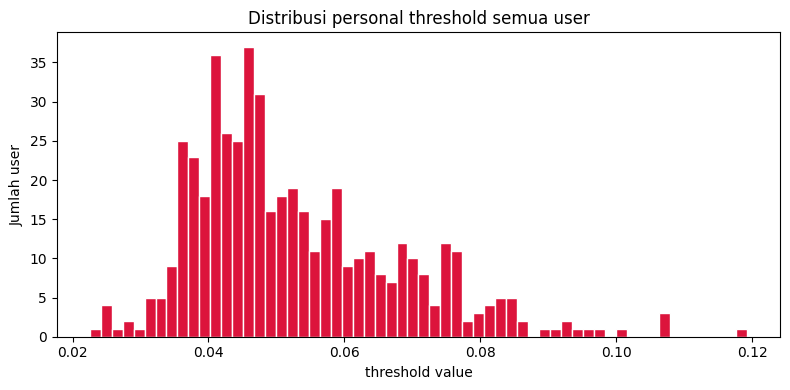

In [ ]:
K_SIGMA = 1.5

# Jumlah kolom kategori (dipakai untuk active-day mask)
N_CAT = FEATURE_COLS.index('gaji_bulanan')

# MSE per hari: shape [n_windows, 14]
X_train_pred      = model.predict(X_train)
mse_train_per_day = np.mean((X_train - X_train_pred) ** 2, axis=2)

threshold_store    = {}
train_user_ids_arr = np.array(train_user_ids)

for uid in unique_train_users:
    user_mask     = train_user_ids_arr == uid
    user_mse_days = mse_train_per_day[user_mask]    # [n_user_windows, 14]
    user_raw_days = X_train_raw[user_mask]          # [n_user_windows, 14, N_FEATURES]

    # Hanya hari aktif: sum kolom kategori (raw, unscaled) > 0
    active_mask = user_raw_days[:, :, :N_CAT].sum(axis=2) > 0       # [n_user_windows, 14]
    user_errors = user_mse_days[active_mask]                        # 1D, hanya hari aktif

    if len(user_errors) == 0:
        continue

    mu        = user_errors.mean()
    sigma     = user_errors.std()
    threshold = mu + (K_SIGMA * sigma)

    threshold_store[uid] = {
        "mu"       : float(mu),
        "sigma"    : float(sigma),
        "threshold": float(threshold),
        "n_hari"   : int(len(user_errors))
    }

# Simpan sebagai pickle dan JSON
with open(MODEL_DIR / "threshold_store.pkl", "wb") as f:
    pickle.dump(threshold_store, f)

with open(MODEL_DIR / "threshold_store.json", "w") as f:
    json.dump(threshold_store, f, indent=2)

# Print 5 sample
print("Sample threshold harian aktif (5 user):")
for uid, v in list(threshold_store.items())[:5]:
    print(f"  {uid} | mu: {v['mu']:.4f} | sigma: {v['sigma']:.4f} "
          f"| threshold: {v['threshold']:.4f} | hari aktif: {v['n_hari']}")

# Plot distribusi threshold
all_thresholds = [v['threshold'] for v in threshold_store.values()]
plt.figure(figsize=(8, 4))
plt.hist(all_thresholds, bins=60, color='crimson', edgecolor='white')
plt.title("Distribusi personal threshold semua user")
plt.xlabel("threshold value")
plt.ylabel("Jumlah user")
plt.tight_layout()
plt.show()

# **INFERENCE**

In [ ]:
# Kolom kategori belanja (exclude profil dan temporal)
CATEGORY_COLS = FEATURE_COLS[:10]

# Mapping decode untuk fitur profil
SEGMEN_MAP  = {0: "Mahasiswa", 1: "First Jobber", 2: "Profesional"}
PERSONA_MAP = {0: "Tightwad",  1: "Unconflicted", 2: "Spendthrift"}

rng = np.random.default_rng(19)

# Pilih user yang ada di val set dan punya threshold
val_users_with_threshold = [u for u in val_user_ids if u in threshold_store]
sample_user = rng.choice(val_users_with_threshold)

# Ambil satu window user tersebut dari X_val
val_user_ids_arr = np.array(val_user_ids)
user_val_indices = np.where(val_user_ids_arr == sample_user)[0]
sample_idx       = int(rng.choice(user_val_indices))
sample_end_date  = val_end_dates[sample_idx]

# Rekonstruksi window (scaled) dan raw window untuk masking
window      = X_val[sample_idx:sample_idx+1]        # [1, 14, N_FEATURES]
window_raw  = X_val_raw[sample_idx:sample_idx+1]    # [1, 14, N_FEATURES] — unscaled
window_pred = model.predict(window, verbose=0)

# Clip prediksi ke [0, 1] sebelum inverse transform untuk mencegah nilai Rupiah negatif
window_pred_clipped = np.clip(window_pred, 0, 1)

# Inverse transform ke nilai rupiah asli
window_actual_rupiah = np.vstack([
    scaler.inverse_transform(window[0, d:d+1, :])[0]
    for d in range(WINDOW_SIZE)
])

window_pred_rupiah = np.vstack([
    scaler.inverse_transform(window_pred_clipped[0, d:d+1, :])[0]
    for d in range(WINDOW_SIZE)
])

# MSE per hari (dari nilai scaled, konsisten dengan threshold)
mse_per_day    = np.mean((window - window_pred) ** 2, axis=2).flatten()  
user_threshold = threshold_store[sample_user]["threshold"]

# Active day mask: hanya hari dengan total belanja kategori > 0 (dari raw unscaled)
N_CAT          = FEATURE_COLS.index('gaji_bulanan')
active_day_mask = window_raw[0, :, :N_CAT].sum(axis=1) > 0    # [14] boolean

# Anomali: error melewati threshold DAN hari tersebut aktif
anomaly_day_indices = np.where((mse_per_day > user_threshold) & active_day_mask)[0]
is_anomaly          = len(anomaly_day_indices) > 0

# Severity berdasarkan rasio hari terparah
if not is_anomaly:
    severity = "none"
else:
    max_ratio = float(mse_per_day[anomaly_day_indices].max()) / user_threshold
    if max_ratio < 1.3:
        severity = "low"
    elif max_ratio < 2:
        severity = "medium"
    else:
        severity = "high"

# Tanggal setiap hari dalam window (H1..H14)
sample_end_ts   = pd.Timestamp(sample_end_date)
window_start_ts = sample_end_ts - pd.Timedelta(days=WINDOW_SIZE - 1)

# Indeks kolom kategori dalam FEATURE_COLS
cat_indices = [FEATURE_COLS.index(c) for c in CATEGORY_COLS]

# Urutkan hari anomali dari error terbesar ke terkecil, batasi top 3
sorted_anomaly_days = anomaly_day_indices[np.argsort(mse_per_day[anomaly_day_indices])[::-1]][:3]

# Detail per anomaly day: top 3 kategori dengan delta rupiah tertinggi
anomaly_days_list    = []
category_total_delta = {c: 0.0 for c in CATEGORY_COLS}

for day_idx in sorted_anomaly_days:
    day_date = (window_start_ts + pd.Timedelta(days=int(day_idx))).strftime("%Y-%m-%d")

    delta_per_cat = np.abs(
        window_actual_rupiah[day_idx, cat_indices] - window_pred_rupiah[day_idx, cat_indices]
    )
    # Zero-out kategori yang actual_amount == 0 agar tidak masuk top categories
    active_cat_mask     = window_raw[0, day_idx, :N_CAT] > 0
    delta_per_cat       = np.where(active_cat_mask, delta_per_cat, 0.0)
    top_3_cat_local_idx = np.argsort(delta_per_cat)[::-1][:3]

    top_categories_detail = []
    for local_ci in top_3_cat_local_idx:
        cat_name   = CATEGORY_COLS[local_ci]
        actual_val = round(float(window_actual_rupiah[day_idx, cat_indices[local_ci]]), 2)
        pred_val   = round(float(window_pred_rupiah[day_idx,   cat_indices[local_ci]]), 2)
        delta_val  = round(float(delta_per_cat[local_ci]), 2)

        top_categories_detail.append({
            "kategori"             : cat_name,
            "actual_amount"        : actual_val,
            "reconstructed_amount" : pred_val,
            "delta"                : delta_val
        })
        category_total_delta[cat_name] += float(delta_per_cat[local_ci])

    anomaly_days_list.append({
        "tanggal"        : day_date,
        "mse_hari"       : round(float(mse_per_day[day_idx]), 6),
        "top_categories" : top_categories_detail
    })

# Most deviant category dan total excess spending
if is_anomaly:
    most_deviant_category = max(category_total_delta, key=category_total_delta.get)
    total_excess_spending = round(sum(category_total_delta.values()), 2)
else:
    most_deviant_category = None
    total_excess_spending = 0.0

# Decode profil user dari baris pertama user di df_val (inverse transform)
user_val_row      = df_val[df_val["id_user"] == sample_user].iloc[0]
user_val_features = user_val_row[FEATURE_COLS].values.reshape(1, -1)
user_original     = scaler.inverse_transform(user_val_features)[0]

gaji_idx    = FEATURE_COLS.index("gaji_bulanan")
segmen_idx  = FEATURE_COLS.index("segmen_demografi_enc")
persona_idx = FEATURE_COLS.index("persona_dasar_enc")

gaji_bulanan  = round(float(user_original[gaji_idx]), 2)
segmen_label  = SEGMEN_MAP.get(int(round(user_original[segmen_idx])),  str(int(round(user_original[segmen_idx]))))
persona_label = PERSONA_MAP.get(int(round(user_original[persona_idx])), str(int(round(user_original[persona_idx]))))

# Susun JSON report
report = {
    "user_id"              : sample_user,
    "window_start"         : window_start_ts.strftime("%Y-%m-%d"),
    "window_end"           : sample_end_ts.strftime("%Y-%m-%d"),
    "is_anomaly"           : bool(is_anomaly),
    "reconstruction_error" : round(float(mse_per_day.mean()), 6),
    "threshold"            : round(user_threshold, 6),
    "severity"             : severity,
    "anomaly_days"         : anomaly_days_list,
    "user_profile"         : {
        "segmen"       : segmen_label,
        "persona"      : persona_label,
        "gaji_bulanan" : gaji_bulanan
    },
    "summary_stats" : {
        "total_anomaly_days"    : int(len(anomaly_day_indices)),
        "most_deviant_category" : most_deviant_category,
        "total_excess_spending" : total_excess_spending
    }
}

print(json.dumps(report, indent=2, ensure_ascii=False))

# Simpan JSON report
report_filename = f"sample_inference_{sample_user}_{sample_end_ts.strftime('%Y-%m-%d')}.json"
with open(MODEL_DIR / report_filename, "w") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print(f"\nReport disimpan: {report_filename}")

{
  "user_id": "USR-322",
  "window_start": "2026-03-10",
  "window_end": "2026-03-23",
  "is_anomaly": true,
  "reconstruction_error": 0.039267,
  "threshold": 0.050666,
  "severity": "high",
  "anomaly_days": [
    {
      "tanggal": "2026-03-10",
      "mse_hari": 0.130955,
      "top_categories": [
        {
          "kategori": "Groceries & Kebutuhan Pokok",
          "actual_amount": 43751.74,
          "reconstructed_amount": 13453.37,
          "delta": 30298.37
        },
        {
          "kategori": "Transportasi",
          "actual_amount": 0.0,
          "reconstructed_amount": 0.0,
          "delta": 0.0
        },
        {
          "kategori": "Tagihan & Utilitas",
          "actual_amount": 0.0,
          "reconstructed_amount": 42785.69,
          "delta": 0.0
        }
      ]
    },
    {
      "tanggal": "2026-03-11",
      "mse_hari": 0.081043,
      "top_categories": [
        {
          "kategori": "Tagihan & Utilitas",
          "actual_amount": 357754.18,

#### **Hari transaksi user-322**

In [20]:
# 1. Filter data khusus untuk USR-437
df_usr437 = df_val[df_val['id_user'] == 'USR-322'].copy()

# 2. Urutkan berdasarkan tanggal agar rapi
df_usr437 = df_usr437.sort_values('tanggal')

# 3. Pilih kolom tanggal dan kategori pengeluaran saja
kolom_kategori = [
    'tanggal',
    'Belanja Online & Fashion',
    'F&B dan Nongkrong',
    'Groceries & Kebutuhan Pokok',
    'Hiburan & Langganan',
    'Investasi & Finansial',
    'Kesehatan & Perawatan Diri',
    'NLP Classified Transfer',
    'Produktivitas & Digital',
    'Tagihan & Utilitas',
    'Transportasi'
]

df_usr437_kategori = df_usr437[kolom_kategori].copy()

# 4. Beri tanda khusus untuk window 14 hari terakhir dan hari anomali
tanggal_mulai = '2026-03-10'
tanggal_akhir = '2026-03-23'
hari_anomali  = ['2026-03-10', '2026-03-11']

def tandai_status(tgl):
    tgl_str = str(tgl)[:10]
    if tgl_str in hari_anomali:
        return '🚨 ANOMALI'
    elif tanggal_mulai <= tgl_str <= tanggal_akhir:
        return '🔍 Dalam Window'

df_usr437_kategori['Status'] = df_usr437_kategori['tanggal'].apply(tandai_status)

# Pindahkan kolom Status ke depan (setelah tanggal)
cols = ['tanggal', 'Status'] + [c for c in df_usr437_kategori.columns if c not in ['tanggal', 'Status']]
df_usr437_kategori = df_usr437_kategori[cols]

# Inverse transform ke nilai Rupiah
cat_indices = [FEATURE_COLS.index(c) for c in kolom_kategori[1:]]

for idx, cat_name in enumerate(kolom_kategori[1:]):
    # Buat array dummy penuh nol sebesar N_FEATURES untuk melewati proses scaler
    dummy_array = np.zeros((len(df_usr437_kategori), len(FEATURE_COLS)))
    
    # Isi kolom yang relevan dengan data scaled
    dummy_array[:, cat_indices[idx]] = df_usr437_kategori[cat_name]
    
    # Kembalikan ke bentuk Rupiah dan timpa ke dataframe
    df_usr437_kategori[cat_name] = scaler.inverse_transform(dummy_array)[:, cat_indices[idx]]
    df_usr437_kategori[cat_name] = df_usr437_kategori[cat_name].round(2)


print(f"Total hari di data validasi untuk USR-322: {len(df_usr437_kategori)} hari\n")
display(df_usr437_kategori)

Total hari di data validasi untuk USR-322: 18 hari



,tanggal,Status,Belanja Online & Fashion,F&B dan Nongkrong,Groceries & Kebutuhan Pokok,Hiburan & Langganan,Investasi & Finansial,Kesehatan & Perawatan Diri,NLP Classified Transfer,Produktivitas & Digital,Tagihan & Utilitas,Transportasi
5284,2026-03-10,🚨 ANOMALI,0.0,0.0,43751.74,0.0,0.0,0.00,0.0,0.00,0.00,0.00
5285,2026-03-11,🚨 ANOMALI,10000.0,0.0,41327.58,0.0,0.0,0.00,0.0,33491.57,357754.18,206764.79
5286,2026-03-12,🔍 Dalam Window,0.0,0.0,3413.12,0.0,0.0,0.00,0.0,0.00,0.00,0.00
5287,2026-03-13,🔍 Dalam Window,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00
5288,2026-03-14,🔍 Dalam Window,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,12171.85
5289,2026-03-15,🔍 Dalam Window,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00
5290,2026-03-16,🔍 Dalam Window,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00
5291,2026-03-17,🔍 Dalam Window,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00
5292,2026-03-18,🔍 Dalam Window,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00
5293,2026-03-19,🔍 Dalam Window,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00


# **SUMMARY**

In [19]:
# Checklist output files
output_files = [
    "lstm_ae_personalized.keras",
    "scaler.pkl",
    "threshold_store.pkl",
    "threshold_store.json",
]
print("Output files:")
for fname in output_files:
    status = 'OK' if (MODEL_DIR / fname).exists() else 'X'
    print(f"[{status}] {fname}")

# Config snapshot
run_id = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

config = {
    "run_id"                : run_id,
    "window_size"           : WINDOW_SIZE,
    "stride"                : STRIDE,
    "encoder_units"         : ENCODER_UNITS,
    "decoder_units"         : DECODER_UNITS,
    "dropout_rate"          : DROPOUT_RATE,
    "learning_rate"         : LEARNING_RATE,
    "epochs_configured"     : EPOCHS,
    "epochs_actual"         : callback.stopped_epoch or EPOCHS,
    "batch_size"            : BATCH_SIZE,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "k_sigma"               : K_SIGMA,
    "n_features"            : N_FEATURES,
    "feature_cols"          : FEATURE_COLS,
    "best_val_loss"         : float(callback.best_val_loss),
    "scaling"               : "MinMaxScaler",
    "model_path"            : str(MODEL_DIR / "lstm_ae_personalized.keras"),
    "notes"                 : "Eksperimen awal pakai .fit(). GradientTape untuk final submission."
}

config_path = MODEL_DIR / f"config_{run_id}.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"\nConfig disimpan: config_{run_id}.json")

Output files:
[OK] lstm_ae_personalized.keras
[OK] scaler.pkl
[OK] threshold_store.pkl
[OK] threshold_store.json

Config disimpan: config_20260513_174025.json
